# Is the low-k feature in the PDS glass runs real?

The z = 0 spectrum of the 1024³ glass run and its phase-matched 256³ partner shows a local
maximum at **k ≈ 0.021 1/Mpc**, the second bin of the 600 Mpc analysis cube. The older 256³
run does not. This notebook asks whether that is a property of the simulations or of the
particular realization they sample.

Two independent tests, both at fixed cosmology, box, R_curv and glass load:

1. **An independent seed** — a fresh realization (C).
2. **A complementary run** — the construction of Rácz, Kiessling, Csabai & Szapudi (2022),
   [arXiv:2210.15077](https://arxiv.org/abs/2210.15077), implemented in stepsic as
   `COMPLEMENTARY = true`. Amplitudes are rescaled shell by shell so that the *pair*
   reproduces the target linear spectrum exactly, eq. (9): `P_C(k) = 2·P_target(k) − P_IC(k)`
   (with the eq. 12 cap where exact compensation would demand negative power). If the
   feature were a Gaussian fluctuation of the initial mode amplitudes, the complement
   should show the opposite excursion and the pair mean should be flat.

*Caveat carried over from the other notebooks:* run A used 1LPT and the rest 2LPT. That was
checked directly and is irrelevant at these scales — an IC generated in realization B with
1LPT gives P(k=0.0209) = 128.3 against 128.5 for 2LPT, and 128.2 with the discrete S³/I*
modes switched off.


In [1]:
import numpy as np, h5py, os
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72

HALF   = 300.0                      # analysis cube half-width [Mpc], as in the other notebooks
NG     = 60                         # FFT mesh (60, not 64: see power_spectrum() there)
ZLIST  = [30,15,10,5,3,2,1,0.7,0.5,0.2,0]
IDX_OF = {z:i for i,z in enumerate(ZLIST)}

# Five 256³/1024³ PDS glass runs. All share cosmology, box, R_curv and particle load type;
# they differ ONLY in which realization of the initial density field they sample.
#
#   A  = the original seed-137 field, drawn in configuration space on a 256³ mesh
#   B  = the seed-137 field drawn on a 1024³ mesh (PHASE_REF_NMESH=1024, cropped in
#        k-space) — this is what the 1024³ run uses, and what its phase-matched 256³
#        partner reproduces
#   B' = the COMPLEMENTARY of B (Rácz, Kiessling, Csabai & Szapudi 2022,
#        arXiv:2210.15077): amplitudes rescaled per shell so that the pair B, B' averages
#        to the target linear spectrum exactly
#   C  = an independent seed
RUNS = {
 'A: StePS PDS 256³'       : dict(dir='/scratch/csabai/test256glass_v2',        w=4, real='A' , kind='pds',    c='tab:gray'),
 'A: Gadget T³ 256³ glass' : dict(dir='/scratch/csabai/gadget256_glass',        w=3, real='A' , kind='gadget', c='dimgray'),
 'A: Gadget T³ 256³ grid'  : dict(dir='/scratch/csabai/gadget256_flat',         w=3, real='A' , kind='gadget', c='silver'),
 'C: StePS PDS 256³'       : dict(dir='/scratch/csabai/test256glass_seed2_run', w=4, real='C' , kind='pds',    c='tab:green'),
 'C: Gadget T³ 256³ glass' : dict(dir='/scratch/csabai/gadget256_glassC',       w=3, real='C' , kind='gadget', c='darkgreen'),
 'B: StePS PDS 256³'       : dict(dir='/scratch/csabai/test256glass_pm_run',    w=4, real='B' , kind='pds',    c='tab:blue'),
 'B: Gadget T³ 256³ glass' : dict(dir='/scratch/csabai/gadget256_glassB',       w=3, real='B' , kind='gadget', c='navy'),
 "B′: StePS PDS 256³ compl": dict(dir='/scratch/csabai/test256glass_comp_run',  w=4, real="B′", kind='pds',    c='tab:red'),
 'B: StePS PDS 1024³'      : dict(dir='/scratch/csabai/test1024glass_run',      w=4, real='B' , kind='pds',    c='k'),
}
HUB = 0.67702

def cube(run, z, chunk=20_000_000):
    """Particles inside the central cube, matched frame, median-centred.  Chunked, so the
    24 GB 1024³ snapshots never land in memory whole.  Gadget snapshots are Mpc/h in box
    coordinates and are mapped with x/h - L/2; PDS ones are already stereographic and
    origin-centred (see Gadget_vs_PDS_comparison.ipynb for the frame derivation)."""
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], IDX_OF[z]))
    conv = (lambda a: a/HUB - 600.0) if run['kind'] == 'gadget' else (lambda a: a)
    with h5py.File(f, 'r') as h:
        X = h['PartType1/Coordinates']; N = X.shape[0]
        med = np.median(conv(X[::max(1, N//5_000_000)].astype(np.float64)), 0)
        keep = []
        for i0 in range(0, N, chunk):
            c = conv(X[i0:i0+chunk].astype(np.float64)) - med
            keep.append(c[(np.abs(c) < HALF).all(1)])
    return np.concatenate(keep)

def pk(xx, ng=NG, shot='auto'):
    """Same estimator as power_spectrum() in Gadget_vs_PDS_comparison.ipynb, for particles
    already cut to the cube."""
    L = 2*HALF; xx = xx + HALF; N = len(xx)
    i = np.clip((xx/L*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (i[:,0], i[:,1], i[:,2]), 1.0)
    P = np.abs(np.fft.fftn(g/g.mean()-1.0))**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    ks, Pr = [], []
    for q in range(1, ng//2):
        s = (kk>=(q-0.5)*kf) & (kk<(q+0.5)*kf)
        if s.sum(): ks.append(q*kf); Pr.append(P[s].mean())
    ks, Pr = np.array(ks), np.array(Pr)
    return ks, Pr - (0.0 if shot=='none' else min(L**3/N, float(Pr.min())))

# modes per bin -> the sample variance floor on any single-bin measurement
kf = 2*np.pi/(2*HALF)
KK = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(NG,1/NG)**2]*3, indexing='ij')))*kf
NMODE = {q: int(((KK>=(q-0.5)*kf)&(KK<(q+0.5)*kf)).sum()) for q in range(1,6)}
print('modes per bin:', {f'{q*kf:.4f}': n for q,n in NMODE.items()})
print('sigma_P/P    :', {f'{q*kf:.4f}': round(float(np.sqrt(2/n)),3) for q,n in NMODE.items()})


modes per bin: {'0.0105': 18, '0.0209': 62, '0.0314': 98, '0.0419': 210, '0.0524': 350}
sigma_P/P    : {'0.0105': 0.333, '0.0209': 0.18, '0.0314': 0.143, '0.0419': 0.098, '0.0524': 0.076}


## 1. Every run at z = 0


  A: StePS PDS 256³          done


  A: Gadget T³ 256³ glass    done


  A: Gadget T³ 256³ grid     done


  C: StePS PDS 256³          done


  C: Gadget T³ 256³ glass    done


  B: StePS PDS 256³          done


  B: Gadget T³ 256³ glass    done


  B′: StePS PDS 256³ compl   done


  B: StePS PDS 1024³         done



z = 0   peak sharpness  P(k=0.0209) / P(k=0.0314)
                       run  realization    ratio
         A: StePS PDS 256³            A    1.209
   A: Gadget T³ 256³ glass            A    1.227
    A: Gadget T³ 256³ grid            A    1.311
         C: StePS PDS 256³            C    1.597
   C: Gadget T³ 256³ glass            C    1.500
         B: StePS PDS 256³            B    1.916
   B: Gadget T³ 256³ glass            B    1.833
  B′: StePS PDS 256³ compl           B′    2.407
        B: StePS PDS 1024³            B    1.998
          mean of B and B′         B,B′    2.139

   realization A : mean 1.249, spread 0.102   (3 runs)
   realization C : mean 1.549, spread 0.097   (2 runs)
   realization B : mean 1.916, spread 0.165   (3 runs)

   modes per bin: 62 (k=0.0209) and 98 (k=0.0314)  -> ~23% sample variance on the ratio


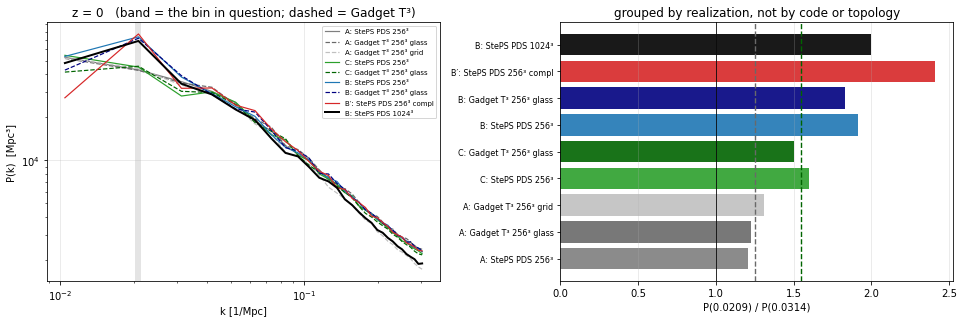

In [2]:
# z = 0 spectra of every run, grouped by realization
D = {}
for lab, r in RUNS.items():
    k, P = pk(cube(r, 0)); D[lab] = (k, P)
    print(f'  {lab:26s} done', flush=True)
k = D['B: StePS PDS 1024³'][0]

print('\nz = 0   peak sharpness  P(k=0.0209) / P(k=0.0314)')
print(f"{'run':>26}{'realization':>13}{'ratio':>9}")
sharp = {}
for lab, r in RUNS.items():
    sharp[lab] = D[lab][1][1]/D[lab][1][2]
    print(f'{lab:>26}{r["real"]:>13}{sharp[lab]:>9.3f}')
pmv, cpv = D['B: StePS PDS 256³'][1], D["B′: StePS PDS 256³ compl"][1]
print(f'{"mean of B and B′":>26}{"B,B′":>13}{(pmv[1]+cpv[1])/(pmv[2]+cpv[2]):>9.3f}')

byr = {}
for lab, r in RUNS.items():
    byr.setdefault(r['real'], []).append(sharp[lab])
print()
for r in ('A', 'C', 'B'):
    v = byr[r]
    print(f'   realization {r:2s}: mean {sum(v)/len(v):.3f}, spread {max(v)-min(v):.3f}   ({len(v)} runs)')
print(f'\n   modes per bin: {NMODE[2]} (k=0.0209) and {NMODE[3]} (k=0.0314)'
      f'  -> ~{100*np.sqrt(2/NMODE[2]+2/NMODE[3]):.0f}% sample variance on the ratio')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.6))
for lab, r in RUNS.items():
    kk, PP = D[lab]
    a1.loglog(kk, PP, color=r['c'], lw=2.0 if '1024' in lab else 1.2,
              ls='-' if r['kind'] == 'pds' else '--', label=lab)
a1.axvline(0.0209, color='0.7', lw=6, alpha=.35, zorder=0)
a1.set_xlabel('k [1/Mpc]'); a1.set_ylabel('P(k)  [Mpc³]')
a1.set_title('z = 0   (band = the bin in question; dashed = Gadget T³)')
a1.grid(alpha=.3); a1.legend(fontsize=7)
names = list(RUNS)
a2.barh(range(len(names)), [sharp[l] for l in names],
        color=[RUNS[l]['c'] for l in names], alpha=.9)
for r, cc in (('A','dimgray'), ('C','darkgreen')):
    a2.axvline(sum(byr[r])/len(byr[r]), color=cc, ls='--', lw=1.4)
a2.axvline(1.0, color='k', lw=.8)
a2.set_yticks(range(len(names))); a2.set_yticklabels(names, fontsize=8)
a2.set_xlabel('P(0.0209) / P(0.0314)')
a2.set_title('grouped by realization, not by code or topology')
a2.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()


## 2. Does the complementary construction actually hold?

Before drawing conclusions from it, verify the machinery on `delta_k` itself, where the
claim is exact and testable to machine precision.


shell power relative to the target spectrum
   single run : mean 1.0217,  scatter 0.0875,  max|dev| 0.2644
   B and B′   : mean 1.0000,  scatter 0.0000,  max|dev| 0.0000

   -> the construction is exact: the PAIR reproduces P_target mode-shell by mode-shell.


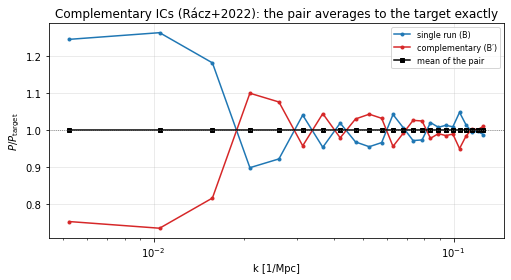

In [3]:
# Does the COMPLEMENTARY construction do what it claims?  Check it on delta_k directly,
# where the statement is exact: the pair's shell-averaged power must equal the target.
import sys
sys.path.insert(0, '/users/csabai/GitHub/steps_dodeca/stepsic')
from stepsic.field import white_noise, generate_delta_k, cubic_voxels, fourier_grid
from scipy.interpolate import CubicSpline

N = 64; L = np.array([1200.0]*3)
nvox, dk = cubic_voxels(N, L)
kh = np.logspace(-4, 1, 300)
pkt = 1e4*kh**0.96/(1+(kh/0.02)**3.6)          # a toy spectrum with a turnover
f  = white_noise(nvox=nvox, seed=137, dtype=np.float64)
dA = generate_delta_k(kh, pkt, nvox, dk, field=f, dtype=np.float64)
dC = generate_delta_k(kh, pkt, nvox, dk, field=f, dtype=np.float64, complementary=True)

_, kmod = fourier_grid(nvox, dk, hermitian=True, dtype=np.float64)
kfs  = np.min(2*np.pi/(np.asarray(nvox)*dk))
ish  = np.rint(kmod/kfs).astype(int); nb = ish.max()+1
cnt  = np.maximum(np.bincount(ish.ravel(), minlength=nb), 1)
shell = lambda x: np.bincount(ish.ravel(), weights=(np.abs(x)**2).ravel(), minlength=nb)/cnt
sp  = CubicSpline(np.log(kh), np.log(pkt))
tg  = np.zeros_like(kmod); m = kmod > 0
tg[m] = np.exp(sp(np.log(kmod[m])))/dk**3
PT  = np.bincount(ish.ravel(), weights=tg.ravel(), minlength=nb)/cnt*np.prod(nvox)
PA, PC = shell(dA), shell(dC)

sel = np.arange(1, 25)
one = PA[sel]/PT[sel]; both = 0.5*(PA[sel]+PC[sel])/PT[sel]
print('shell power relative to the target spectrum')
print(f'   single run : mean {one.mean():.4f},  scatter {one.std():.4f},  max|dev| {np.abs(one-1).max():.4f}')
print(f'   B and B′   : mean {both.mean():.4f},  scatter {both.std():.4f},  max|dev| {np.abs(both-1).max():.4f}')
print('\n   -> the construction is exact: the PAIR reproduces P_target mode-shell by mode-shell.')

fig, ax = plt.subplots(figsize=(7.2, 4.0))
kax = sel*kfs
ax.plot(kax, one,  'o-', ms=3, color='tab:blue', label='single run (B)')
ax.plot(kax, PC[sel]/PT[sel], 'o-', ms=3, color='tab:red', label="complementary (B′)")
ax.plot(kax, both, 's-', ms=4, color='k', label='mean of the pair')
ax.axhline(1, color='0.4', lw=.8, ls=':')
ax.set_xscale('log'); ax.set_xlabel('k [1/Mpc]'); ax.set_ylabel(r'$P/P_{\rm target}$')
ax.set_title('Complementary ICs (Rácz+2022): the pair averages to the target exactly')
ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 3. What the fundamental bin is actually measuring

The lowest bin carries ~2000 Mpc³ in every PDS *glass* run and ~0 in the *grid* runs. Before
blaming the glass, check the load itself — a glass has no cosmological signal, so its P(k)
**is** the static noise.


In [4]:
# ── The Omega^3 chart gradient, and what the glass relaxation actually controls ──
# The glass load is uniform on S^3, so its COUNT density in the stereographic chart carries
# the smooth radial volume factor Omega^3 = (2R^2/(R^2+r^2))^3.  pk() above weights by raw
# counts and picks that up as large-scale power.  De-conformalizing (weight 1/Omega^3) is
# what delta_slice() already does for the density slices.
R_CURV = 3100.0

def pk_w(path, deconf=False, ng=NG, chunk=20_000_000, shot='auto'):
    f = h5py.File(path); X = f['PartType1/Coordinates']; N = X.shape[0]
    med = np.median(X[::max(1, N//5_000_000)].astype(np.float64), 0)
    L = 2*HALF; g = np.zeros((ng,)*3); nn = 0
    for i0 in range(0, N, chunk):
        c = X[i0:i0+chunk].astype(np.float64) - med
        m = (np.abs(c) < HALF).all(1); c = c[m]; nn += len(c)
        w = (1.0/(2.0*R_CURV**2/(R_CURV**2 + (c**2).sum(1)))**3) if deconf else np.ones(len(c))
        i = np.clip(((c+HALF)/L*ng).astype(int), 0, ng-1)
        np.add.at(g, (i[:,0], i[:,1], i[:,2]), w)
    P = np.abs(np.fft.fftn(g/g.mean()-1.0))**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    ks, Pr = [], []
    for q in range(1, ng//2):
        s = (kk>=(q-0.5)*kf) & (kk<(q+0.5)*kf)
        if s.sum(): ks.append(q*kf); Pr.append(P[s].mean())
    ks, Pr = np.array(ks), np.array(Pr)
    return ks, Pr - (0.0 if shot=='none' else min(L**3/nn, float(Pr.min())))

LOADS = {'Poisson preglass (unrelaxed)':
             '/scratch/csabai/glass256/g256eds_pds_preglass_Rcurv3100_L1200_Np6275736_Nm256/ic.hdf5',
         'glass relaxed to a = 1.01':  '/scratch/csabai/glass256_run/snapshot_0005.hdf5',
         'glass relaxed to a = 16':    '/scratch/csabai/glass256_long_run/snapshot_0003.hdf5'}
print('P(k) of the LOAD itself in the fundamental bin  [Mpc³]')
print(f"{'load':>32}{'raw counts':>13}{'de-conformalized':>19}")
for l, p in LOADS.items():
    a = pk_w(p, False, shot='none')[1][0]; b = pk_w(p, True, shot='none')[1][0]
    print(f'{l:>32}{a:>13.1f}{b:>19.1f}')
print('\n  -> ~99% of it is the chart gradient: it is already there in the UNRELAXED Poisson')
print('     load, and a 16x longer relaxation does not touch it (2091 -> 2076).')


P(k) of the LOAD itself in the fundamental bin  [Mpc³]
                            load   raw counts   de-conformalized


    Poisson preglass (unrelaxed)       2256.7              145.1


       glass relaxed to a = 1.01       2090.9               18.0


         glass relaxed to a = 16       2076.3                9.1

  -> ~99% of it is the chart gradient: it is already there in the UNRELAXED Poisson
     load, and a 16x longer relaxation does not touch it (2091 -> 2076).


## 4. Does a longer glass relaxation change anything?

The reverse-gravity relaxation was extended from a = 1.01 to a = 16 (43 min at 256³), and a
256³ run built from it — same realization, same 2LPT, only the load differs.


z = 0, mean ratio for k > 0.18
   glass(a=16)   / glass(a=1.01) : 0.811
   glass(a=1.01) / grid          : 1.208   <- the anomaly
   glass(a=16)   / grid          : 0.979   <- cured

   peak sharpness P(0.0209)/P(0.0314): a=1.01 1.916,  a=16 2.035  (unchanged -> not load noise)


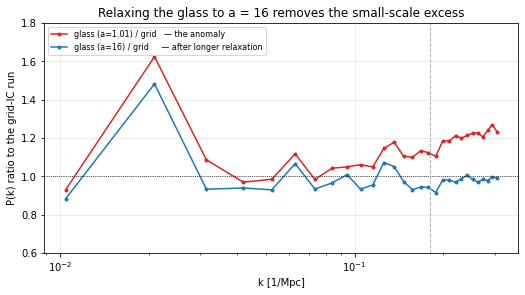

In [5]:
# ── Does a longer glass relaxation cure the glass anomaly? ────────────────────
# Controlled test: same realization (B), same 2LPT, same PHASE_REF_NMESH -- only the glass
# load differs (relaxed to a = 1.01 vs a = 16).
CMP = {'glass a=1.01 (B)': '/scratch/csabai/test256glass_pm_run',
       'glass a=16   (B)': '/scratch/csabai/test256glass_longrelax_run',
       'grid'            : '/scratch/csabai/test256disc_v2'}
Z0 = {l: pk_w(f'{d}/snapshot_{IDX_OF[0]:04d}.hdf5') for l, d in CMP.items()}
kk = Z0['grid'][0]
g1, g2, gr = (Z0['glass a=1.01 (B)'][1], Z0['glass a=16   (B)'][1], Z0['grid'][1])
n = min(map(len, (g1, g2, gr))); hi = kk[:n] > 0.18

print('z = 0, mean ratio for k > 0.18')
print(f'   glass(a=16)   / glass(a=1.01) : {np.mean(g2[:n][hi]/g1[:n][hi]):.3f}')
print(f'   glass(a=1.01) / grid          : {np.mean(g1[:n][hi]/gr[:n][hi]):.3f}   <- the anomaly')
print(f'   glass(a=16)   / grid          : {np.mean(g2[:n][hi]/gr[:n][hi]):.3f}   <- cured')
print(f'\n   peak sharpness P(0.0209)/P(0.0314): '
      f'a=1.01 {g1[1]/g1[2]:.3f},  a=16 {g2[1]/g2[2]:.3f}  (unchanged -> not load noise)')

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.semilogx(kk[:n], g1[:n]/gr[:n], 'o-', ms=3, color='tab:red',
            label='glass (a=1.01) / grid   — the anomaly')
ax.semilogx(kk[:n], g2[:n]/gr[:n], 'o-', ms=3, color='tab:blue',
            label='glass (a=16) / grid     — after longer relaxation')
ax.axhline(1, color='k', lw=.8, ls=':'); ax.axvline(0.18, color='0.7', lw=1, ls='--')
ax.set_xlabel('k [1/Mpc]'); ax.set_ylabel('P(k) ratio to the grid-IC run')
ax.set_ylim(0.6, 1.8); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title('Relaxing the glass to a = 16 removes the small-scale excess')
plt.tight_layout(); plt.show()


## 5. The decisive test: one realization, two codes, two topologies

§1 already contains the pieces; this isolates the comparison that matters.

Each realization was carried into **Gadget4 — flat T³, FMM/TreePM, its own flat glass load**.
Each cubical IC was generated with the same `SEED` and the same `PHASE_REF_NMESH` as its
StePS counterpart, so it samples the same `delta_k` modes and shares nothing else.
Verified on the ICs: the cubical and PDS fields of a realization cross-correlate at
r ≈ 0.81 at k = 0.021, while the cross-pair (cubical B × PDS C) gives r ≈ 0.

**Realization B matters most**: it is the one carrying the strong peak (1.83–2.00), and
until its Gadget counterpart existed every B run was a PDS run — so "the peak only appears
in PDS" and "the peak follows the realization" made identical predictions for A and C.
Only B separates them.


In [6]:
# The same numbers as §1, grouped so the realization split is explicit.
sh = {}
for lab, r in RUNS.items():
    if r['real'] in ('A', 'B', 'C'):        # B′ is a rescaling of B, not an independent draw
        sh.setdefault(r['real'], []).append((lab, D[lab][1][1]/D[lab][1][2]))

print('z = 0   peak sharpness  P(0.0209) / P(0.0314)')
print(f"{'run':>26}{'realization':>13}{'ratio':>9}")
for r in ('A', 'C', 'B'):
    for lab, v in sh[r]:
        print(f'{lab:>26}{r:>13}{v:>9.3f}')
    vv = [v for _, v in sh[r]]
    print(f"{'':>26}{'mean ' + r:>13}{sum(vv)/len(vv):>9.3f}   (spread {max(vv)-min(vv):.3f})")

mean = {r: sum(v for _, v in sh[r])/len(sh[r]) for r in sh}
sprd = {r: max(v for _, v in sh[r]) - min(v for _, v in sh[r]) for r in sh}
print(f'\n  separation between realizations: '
      f'B-A = {mean["B"]-mean["A"]:.3f},  C-A = {mean["C"]-mean["A"]:.3f}')
print(f'  largest spread WITHIN a realization: {max(sprd.values()):.3f}')
print('\n  In realization B the Gadget T³ run reproduces the strong peak '
      f'({dict(sh["B"])["B: Gadget T³ 256³ glass"]:.3f}) that the PDS runs show '
      f'({dict(sh["B"])["B: StePS PDS 256³"]:.3f}, '
      f'{dict(sh["B"])["B: StePS PDS 1024³"]:.3f}).')
print('  -> the feature is set by the initial realization, not by the PDS topology.')


z = 0   peak sharpness  P(0.0209) / P(0.0314)
                       run  realization    ratio
         A: StePS PDS 256³            A    1.209
   A: Gadget T³ 256³ glass            A    1.227
    A: Gadget T³ 256³ grid            A    1.311
                                 mean A    1.249   (spread 0.102)
         C: StePS PDS 256³            C    1.597
   C: Gadget T³ 256³ glass            C    1.500
                                 mean C    1.549   (spread 0.097)
         B: StePS PDS 256³            B    1.916
   B: Gadget T³ 256³ glass            B    1.833
        B: StePS PDS 1024³            B    1.998
                                 mean B    1.916   (spread 0.165)

  separation between realizations: B-A = 0.667,  C-A = 0.300
  largest spread WITHIN a realization: 0.165

  In realization B the Gadget T³ run reproduces the strong peak (1.833) that the PDS runs show (1.916, 1.998).
  -> the feature is set by the initial realization, not by the PDS topology.


## 6. What this shows

Three separate effects were tangled together at low k. They have different causes.

### The k = 0.021 maximum is set by the realization, not by the PDS topology

The concern this notebook has to answer is that the *strong* peak appeared only in PDS runs.
That was true of the data at one point: realizations A (1.21) and C (1.55) are mild, and
every run carrying the strong peak — 1.92, 2.00, 2.41 — was a StePS PDS run of realization
B. For A and C, "it is the realization" and "it is something about PDS" made the same
prediction, so neither was tested.

**Realization B in Gadget4 settles it.** Same `SEED`, same `PHASE_REF_NMESH`, hence the same
`delta_k`; flat T³ torus, FMM/TreePM, its own flat glass load, nothing else shared:

| realization | runs | mean | spread |
|---|---|---|---|
| A | StePS PDS, Gadget T³ glass, Gadget T³ grid | 1.249 | 0.102 |
| C | StePS PDS, Gadget T³ glass | 1.549 | 0.097 |
| **B** | StePS PDS 256³ **1.916**, Gadget T³ glass **1.833**, StePS PDS 1024³ **1.998** | **1.916** | 0.165 |

Gadget reproduces the strong peak. The raw spectra agree closely too — at k = 0.0209,
71816 Mpc³ (Gadget T³) against 73440 (StePS PDS). Separations between realizations
(B−A = 0.667, C−A = 0.300) are several times the largest spread *within* one (0.165).

So the feature travels with the initial modes across two codes, two topologies and two
loads. It is sample variance in a 62-mode bin, not a property of S³/I*.

### The fundamental-bin "load noise" is a coordinate artifact

The ~2000 Mpc³ in the lowest bin is **99% the Ω³ volume factor of the stereographic
chart**, not glass noise. The glass load is uniform on S³, so its *count* density in the
chart carries a smooth radial gradient, and a count-weighted P(k) reads that as large-scale
power. It is present at full strength in the **unrelaxed Poisson** load, is identical at
256³ and 1024³, and a 16× longer relaxation leaves it untouched.

The PDS **grid** run does not show it (F = −13.9) because that load is a uniform *chart*
lattice with Ω³-weighted masses — uniform counts, no gradient.

> **This corrects an earlier reading**, in which the same number was taken as evidence that
> the glass's largest-scale modes never relax. It is not. The fix is on the estimator side:
> `power_spectrum()` in the comparison notebooks weights by raw counts and should offer the
> de-conformalized weighting that `delta_slice()` already uses.

### The glass anomaly *is* insufficient relaxation — and it is curable

Relaxing to a = 16 instead of a = 1.01 removes the excess almost entirely: the glass/grid
ratio at k > 0.18 goes **1.208 → 0.979**. This is the same effect that appears as ~1.7×
halo abundance and ~2× matched-pair masses in `halo_catalogs/README`.

**Recommendation: relax to a ≥ 4 for production glass ICs** (most of the gain is in place
by then — nearest-neighbour sd/mean 0.107 → 0.066). Glass-IC runs relaxed only to a = 1
should not be used for halo statistics.
